# Main Workflow — HARNN Multi-Label Text Classification

File gộp từ 4 notebook theo thứ tự:
1. **Preprocessing** — Tiền xử lý dữ liệu
2. **Training** — Huấn luyện Word2Vec + HARNN
3. **Prediction** — Dự đoán nhãn
4. **Evaluation** — Đánh giá mô hình

> Tất cả đường dẫn sử dụng relative path từ thư mục gốc project.


## Imports & Cấu hình chung


In [1]:
import json, re, warnings, time, random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from gensim.models import Word2Vec
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

warnings.filterwarnings('ignore')

# ── Đường dẫn (relative từ thư mục gốc project) ──
PROJECT_DIR   = Path('.').resolve().parent
DATA_DIR      = PROJECT_DIR / 'data'
RAW_FILE      = DATA_DIR / 'raw_data.json'
PROCESS_DIR   = DATA_DIR / 'process_data'
DICT_DIR      = DATA_DIR / 'dictionary'
OUTPUT_DIR    = PROJECT_DIR / 'output'

OUT_DATASET   = PROCESS_DIR / 'dataset.json'
OUT_VOCAB     = PROCESS_DIR / 'vocab.json'
OUT_LABEL_MAP = PROCESS_DIR / 'label_map.json'
STOPWORDS_FILE      = DICT_DIR / 'vietnamese-stopwords.txt'
STOPWORDS_DASH_FILE = DICT_DIR / 'vietnamese-stopwords-dash.txt'

# Tạo thư mục
PROCESS_DIR.mkdir(parents=True, exist_ok=True)
for d in ['models/checkpoints', 'results', 'figures', 'log']:
    (OUTPUT_DIR / d).mkdir(parents=True, exist_ok=True)

# ── Tham số chung ──
MIN_TOKENS      = 20
VOCAB_MIN_COUNT = 3
MAX_LEN         = 512
BATCH_SIZE      = 16
SEED            = 42
EMBED_DIM       = 100
HIDDEN_SIZE     = 256
THRESHOLD       = 0.5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Project: {PROJECT_DIR}')


Device: cuda
Project: C:\Users\PC\Multi-Label-Text-Classification


---
# Phần 1: Tiền xử lý dữ liệu (Preprocessing)


## Cell 1.1 — Text processing


In [2]:
with open(STOPWORDS_FILE, encoding='utf-8') as f:
    sw1 = {line.strip() for line in f if line.strip()}
with open(STOPWORDS_DASH_FILE, encoding='utf-8') as f:
    sw2 = {line.strip() for line in f if line.strip()}

STOPWORDS = sw1 | sw2
print(f'File gốc  : {len(sw1)} từ')
print(f'File dash : {len(sw2)} từ')
print(f'Tổng      : {len(STOPWORDS)} từ')


def clean(text: str) -> str:
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()


def tokenize(text: str) -> list[str]:
    try:
        from underthesea import word_tokenize
        tokens = word_tokenize(clean(text), format='text').split()
    except ImportError:
        tokens = clean(text).split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]


def multihot(label: str, idx_map: dict) -> list[int]:
    vec = [0] * len(idx_map)
    if label and label in idx_map:
        vec[idx_map[label]] = 1
    return vec


sample = 'Cứu được người đuối nước khi livestream lúc 12h30 ngày 17/3'
print(f'\nInput : {sample}')
print(f'Tokens: {tokenize(sample)}')


File gốc  : 1942 từ
File dash : 1942 từ
Tổng      : 3513 từ

Input : Cứu được người đuối nước khi livestream lúc 12h30 ngày 17/3
Tokens: ['cứu', 'đuối', 'livestream']


## Cell 1.2 — Load → Build LABEL_MAP → tokenize → encode label


In [3]:
with open(RAW_FILE, encoding='utf-8') as f:
    raw = json.load(f)
print(f'Loaded {len(raw):,} bài')

LABEL_MAP = {'l1': {}, 'l2': {}, 'l3': {}}
unique_labels = {'l1': set(), 'l2': set(), 'l3': set()}
for a in raw:
    for level, key in [('l1', 'label_l1'), ('l2', 'label_l2'), ('l3', 'label_l3')]:
        val = a.get(key, '')
        if val:
            unique_labels[level].add(val)

for level in ['l1', 'l2', 'l3']:
    for idx, val in enumerate(sorted(unique_labels[level])):
        LABEL_MAP[level][val] = idx

print(f"L1: {len(LABEL_MAP['l1'])}  L2: {len(LABEL_MAP['l2'])}  L3: {len(LABEL_MAP['l3'])}")

articles = []
skipped  = 0

for i, a in enumerate(raw):
    l1 = a.get('label_l1', '')
    l2 = a.get('label_l2', '')
    l3 = a.get('label_l3', '')

    if not l1:
        skipped += 1
        continue

    tokens = tokenize(a.get('title', '') + ' ' + a.get('content', ''))
    if len(tokens) < MIN_TOKENS:
        skipped += 1
        continue

    articles.append({
        'url':           a.get('url', ''),
        'title':         a.get('title', ''),
        'tokens':        tokens,
        'labels_l1':     [l1],
        'labels_l2':     [l2] if l2 else [],
        'labels_l3':     [l3] if l3 else [],
        'vec_l1':        multihot(l1, LABEL_MAP['l1']),
        'vec_l2':        multihot(l2, LABEL_MAP['l2']),
        'vec_l3':        multihot(l3, LABEL_MAP['l3']),
        'is_multilabel': False,
    })

    if (i + 1) % 1000 == 0:
        print(f'  {i+1}/{len(raw)}')

print(f'\nHợp lệ : {len(articles):,}')
print(f'Bỏ qua : {skipped:,}')


Loaded 23,660 bài
L1: 12  L2: 47  L3: 20
  1000/23660
  2000/23660
  3000/23660
  4000/23660
  5000/23660
  6000/23660
  7000/23660
  8000/23660
  9000/23660
  10000/23660
  11000/23660
  12000/23660
  13000/23660
  14000/23660
  15000/23660
  16000/23660
  17000/23660
  18000/23660
  19000/23660
  20000/23660
  21000/23660
  22000/23660
  23000/23660

Hợp lệ : 23,580
Bỏ qua : 80


## Cell 1.3 — Build vocab → lưu file


In [4]:
counter = Counter(t for a in articles for t in a['tokens'])
vocab   = {'<PAD>': 0, '<UNK>': 1}
for word, cnt in counter.most_common():
    if cnt >= VOCAB_MIN_COUNT:
        vocab[word] = len(vocab)
print(f'Vocab: {len(vocab):,} từ (min_count={VOCAB_MIN_COUNT})')

with open(OUT_DATASET,   'w', encoding='utf-8') as f: json.dump(articles,  f, ensure_ascii=False, indent=2)
with open(OUT_VOCAB,     'w', encoding='utf-8') as f: json.dump(vocab,     f, ensure_ascii=False, indent=2)
with open(OUT_LABEL_MAP, 'w', encoding='utf-8') as f: json.dump(LABEL_MAP, f, ensure_ascii=False, indent=2)

print(f'\n✓ {OUT_DATASET}')
print(f'✓ {OUT_VOCAB}')
print(f'✓ {OUT_LABEL_MAP}')


Vocab: 69,481 từ (min_count=3)

✓ C:\Users\PC\Multi-Label-Text-Classification\data\process_data\dataset.json
✓ C:\Users\PC\Multi-Label-Text-Classification\data\process_data\vocab.json
✓ C:\Users\PC\Multi-Label-Text-Classification\data\process_data\label_map.json


## Cell 1.4 — Kiểm tra kết quả


In [5]:
total   = len(articles)
has_l2  = sum(1 for a in articles if a['labels_l2'])
has_l3  = sum(1 for a in articles if a['labels_l3'])

print(f'Tổng bài   : {total:,}')
print(f'Có L2      : {has_l2:,} ({has_l2/total*100:.1f}%)')
print(f'Có L3      : {has_l3:,} ({has_l3/total*100:.1f}%)')
print(f'Vocab size : {len(vocab):,}')
print(f'vec_l1 dim : {len(articles[0]["vec_l1"])}')
print(f'vec_l2 dim : {len(articles[0]["vec_l2"])}')
print(f'vec_l3 dim : {len(articles[0]["vec_l3"])}')

l1_dist = Counter(a['labels_l1'][0] for a in articles)
print(f'\nPhân phối L1:')
mx = max(l1_dist.values())
for lb, cnt in sorted(l1_dist.items(), key=lambda x: -x[1]):
    bar = '█' * (cnt * 30 // mx)
    print(f'  {lb:<22} {cnt:>5}  {bar}')

print('\n3 bài mẫu:')
for a in articles[:3]:
    print(f"  {a['title'][:55]}")
    print(f"  L1={a['labels_l1']}  L2={a['labels_l2']}  L3={a['labels_l3']}")
    print(f"  tokens={a['tokens'][:6]}  vec_l1 sum={sum(a['vec_l1'])}")
    print()


Tổng bài   : 23,580
Có L2      : 23,347 (99.0%)
Có L3      : 5,430 (23.0%)
Vocab size : 69,481
vec_l1 dim : 12
vec_l2 dim : 47
vec_l3 dim : 20

Phân phối L1:
  Giải trí                3260  ██████████████████████████████
  Khoa học công nghệ      2963  ███████████████████████████
  Giáo dục                2552  ███████████████████████
  Xe                      2488  ██████████████████████
  Thời sự                 2405  ██████████████████████
  Thế giới                2089  ███████████████████
  Bất động sản            1946  █████████████████
  Đời sống                1872  █████████████████
  Thể thao                1546  ██████████████
  Sức khỏe                1001  █████████
  Kinh doanh               897  ████████
  Pháp luật                561  █████

3 bài mẫu:
  Tự ý xây hạ tầng, rao bán hàng nghìn m2 đất nông lâm tr
  L1=['Bất động sản']  L2=['Thị trường bất động sản']  L3=[]
  tokens=['xây', 'hạ_tầng', 'rao', 'hàng', 'nghìn', 'đất']  vec_l1 sum=1

  Lao động tự do được tự kê 

---
# Phần 2: Huấn luyện mô hình (Training)


## Cell 2.1 — Load data cho training


In [6]:
VOCAB_SIZE = len(vocab)
NUM_CLASSES = [
    len(articles[0]['vec_l1']),
    len(articles[0]['vec_l2']),
    len(articles[0]['vec_l3']),
]
print(f'Data: {len(articles):,} | Vocab: {VOCAB_SIZE:,} | Classes: {NUM_CLASSES}')


Data: 23,580 | Vocab: 69,481 | Classes: [12, 47, 20]


## Cell 2.2 — Dataset & DataLoader


In [7]:
MIN_CROP = 20

class VnExpressDataset(Dataset):
    def __init__(self, articles, vocab, augment=False):
        self.articles, self.vocab, self.augment = articles, vocab, augment

    def __len__(self):
        return len(self.articles)

    def __getitem__(self, idx):
        a = self.articles[idx]
        tokens = a["tokens"]

        if self.augment and len(tokens) > MIN_CROP:
            n = len(tokens)
            c = random.randint(max(MIN_CROP, n * 3 // 10), n)
            start = random.randint(0, n - c)
            tokens = tokens[start : start + c]

        ids = [self.vocab.get(t, 1) for t in tokens][:MAX_LEN]
        ids += [0] * (MAX_LEN - len(ids))

        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(a["vec_l1"], dtype=torch.float),
            torch.tensor(a["vec_l2"], dtype=torch.float),
            torch.tensor(a["vec_l3"], dtype=torch.float),
        )


def split_data(articles, seed=SEED):
    y = np.array([a["vec_l1"] + a["vec_l2"] + a["vec_l3"] for a in articles], dtype=np.int32)
    idx = np.arange(len(articles)).reshape(-1, 1)

    def isplit(x, y, r):
        return next(MultilabelStratifiedShuffleSplit(1, test_size=r, random_state=seed).split(x, y))

    tr, ho = isplit(idx, y, 0.2)
    vl, te = isplit(idx[ho], y[ho], 0.5)

    return (
        [articles[i] for i in tr],
        [articles[ho[i]] for i in vl],
        [articles[ho[i]] for i in te],
    )

train_arts, val_arts, test_arts = split_data(articles)

def make_loader(arts, aug, shuf):
    return DataLoader(
        VnExpressDataset(arts, vocab, aug),
        batch_size=BATCH_SIZE,
        shuffle=shuf,
        num_workers=0,
    )

train_loader = make_loader(train_arts, True, True)
val_loader = make_loader(val_arts, False, False)
test_loader = make_loader(test_arts, False, False)

for name, data in [("train_data", train_arts), ("test_data", test_arts)]:
    with open(DATA_DIR / f"{name}.json", "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

print(f"Train: {len(train_arts):,} | Val: {len(val_arts):,} | Test: {len(test_arts):,}")


Train: 18,865 | Val: 2,353 | Test: 2,362


## Cell 2.3 — Train Word2Vec → embedding matrix


In [8]:
corpus = [a["tokens"] for a in articles]

w2v = Word2Vec(corpus, vector_size=EMBED_DIM, min_count=5, epochs=10, sg=1, workers=4, seed=SEED)
w2v_path = OUTPUT_DIR / "models" / "checkpoints" / "word2vec.model"
w2v_path.parent.mkdir(parents=True, exist_ok=True)
w2v.save(str(w2v_path))

embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)
embed_matrix[1] = w2v.wv.vectors.mean(axis=0)

found = 0
for w, i in vocab.items():
    if w in w2v.wv:
        embed_matrix[i] = w2v.wv[w]
        found += 1

print(f"W2V Vocab: {len(w2v.wv):,} từ | Coverage: {found/(VOCAB_SIZE-2):.2%}")


W2V Vocab: 45,491 từ | Coverage: 65.47%


## Cell 2.4 — HARNN model


In [9]:
class HARNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_classes, pretrained_embeddings=None, dropout=0.5):
        super().__init__()
        self.num_levels = len(num_classes)
        self.hidden_size = hidden_size

        if pretrained_embeddings is not None:
            self.emb = nn.Embedding.from_pretrained(torch.from_numpy(pretrained_embeddings), freeze=False, padding_idx=0)
        else:
            self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            
        self.bigru = nn.GRU(embed_dim, hidden_size, bidirectional=True, batch_first=True)
        self.drop = nn.Dropout(dropout)

        self.attention = nn.ModuleList([nn.Linear(hidden_size * 2, 1) for _ in range(self.num_levels)])
        self.ham = nn.LSTMCell(hidden_size * 2, hidden_size)
        self.classifiers = nn.ModuleList([nn.Linear(hidden_size * 3, n) for n in num_classes])

    def forward(self, x):
        doc = self.drop(self.bigru(self.drop(self.emb(x)))[0])
        
        h, c = (torch.zeros(x.size(0), self.hidden_size, device=x.device) for _ in range(2))
        
        preds = []
        for i in range(self.num_levels):
            ctx = (torch.softmax(self.attention[i](doc), dim=1) * doc).sum(1)
            h, c = self.ham(ctx, (h, c))
            feat = self.drop(torch.cat([ctx, h], dim=-1))
            
            preds.append(self.classifiers[i](feat))
            
        return preds

model = HARNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES, embed_matrix).to(device)

print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
dummy_in = torch.zeros(2, MAX_LEN, dtype=torch.long, device=device)
print(f"Output shapes: {[tuple(o.shape) for o in model(dummy_in)]}")


Params: 8,348,758
Output shapes: [(2, 12), (2, 47), (2, 20)]


## Cell 2.5 — Training loop


In [10]:
NUM_EPOCHS, LR, PATIENCE = 10, 3e-4, 5
LEVEL_WEIGHTS = [1.0, 1.0, 1.2]
CKPT_PATH = OUTPUT_DIR / "models" / "checkpoints" / "best_model.pt"

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)
criterion = nn.BCEWithLogitsLoss()

def run_epoch(loader, training=True):
    model.train(training)
    total_loss = 0
    all_preds, all_labels = [[] for _ in range(3)], [[] for _ in range(3)]

    with torch.set_grad_enabled(training):
        for ids, l1, l2, l3 in loader:
            ids, targets = ids.to(device), [t.to(device) for t in (l1, l2, l3)]
            if training: optimizer.zero_grad()

            preds = model(ids)
            losses = [LEVEL_WEIGHTS[i] * criterion(preds[i], targets[i]) for i in range(3) if targets[i].sum() > 0]

            if losses:
                loss = sum(losses)
                if training:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                    optimizer.step()
                total_loss += loss.item()

            for i in range(3):
                probs = torch.sigmoid(preds[i]).detach().cpu().numpy()
                all_preds[i].append(probs)
                all_labels[i].append(targets[i].cpu().numpy())

    f1s = [f1_score(np.concatenate(all_labels[i]), (np.concatenate(all_preds[i]) >= 0.5).astype(int),
                    average="micro", zero_division=0) if sum(len(x) for x in all_labels[i]) else 0.0 for i in range(3)]
    return total_loss / len(loader), f1s

history = {k: [] for k in ["train_loss", "val_loss", "val_f1_l1", "val_f1_l2", "val_f1_l3"]}
best_f1, no_improve = 0.0, 0

print("Training started...")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, _      = run_epoch(train_loader, True)
    val_loss, v_f1s = run_epoch(val_loader, False)

    for k, v in zip(history.keys(), [tr_loss, val_loss, *v_f1s]): history[k].append(v)

    scheduler.step(v_f1s[0])
    global_f1 = sum(v_f1s) / 3

    status = ""
    if global_f1 > best_f1:
        best_f1 = global_f1
        torch.save({"epoch": epoch, "model_state": model.state_dict(), "val_f1_l1": v_f1s[0], "val_f1s": v_f1s, "global_f1": global_f1}, CKPT_PATH)
        status = " [Saved]"
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            status = " [Early Stop]"

    print(f"Ep {epoch}/{NUM_EPOCHS} | Train: {tr_loss:.4f} | Val: {val_loss:.4f} | F1: {v_f1s[0]:.3f} (L1), {v_f1s[1]:.3f} (L2), {v_f1s[2]:.3f} (L3){status}")

    if "Stop" in status:
        break

with open(OUTPUT_DIR / "results" / "train_history.json", "w") as f: json.dump(history, f, indent=2)
print(f"\nBest Global F1: {best_f1:.3f}")


Training started...
Ep 1/10 | Train: 0.3538 | Val: 0.1615 | F1: 0.821 (L1), 0.296 (L2), 0.114 (L3) [Saved]
Ep 2/10 | Train: 0.1587 | Val: 0.1169 | F1: 0.898 (L1), 0.494 (L2), 0.393 (L3) [Saved]
Ep 3/10 | Train: 0.1276 | Val: 0.0990 | F1: 0.916 (L1), 0.625 (L2), 0.496 (L3) [Saved]
Ep 4/10 | Train: 0.1099 | Val: 0.0888 | F1: 0.921 (L1), 0.696 (L2), 0.567 (L3) [Saved]
Ep 5/10 | Train: 0.0989 | Val: 0.0795 | F1: 0.931 (L1), 0.715 (L2), 0.579 (L3) [Saved]
Ep 6/10 | Train: 0.0899 | Val: 0.0744 | F1: 0.934 (L1), 0.757 (L2), 0.658 (L3) [Saved]
Ep 7/10 | Train: 0.0823 | Val: 0.0733 | F1: 0.934 (L1), 0.766 (L2), 0.706 (L3) [Saved]
Ep 8/10 | Train: 0.0755 | Val: 0.0662 | F1: 0.943 (L1), 0.783 (L2), 0.696 (L3) [Saved]
Ep 9/10 | Train: 0.0700 | Val: 0.0666 | F1: 0.943 (L1), 0.793 (L2), 0.713 (L3) [Saved]
Ep 10/10 | Train: 0.0636 | Val: 0.0679 | F1: 0.945 (L1), 0.785 (L2), 0.718 (L3)

Best Global F1: 0.816


## Cell 2.6 — Đánh giá test set


In [11]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=device)["model_state"])
model.eval()

@torch.no_grad()
def evaluate(loader):
    preds, labels = [[] for _ in range(3)], [[] for _ in range(3)]
    for ids, *targs in loader:
        out = model(ids.to(device))
        for i in range(3):
            preds[i].append(torch.sigmoid(out[i]).cpu().numpy())
            labels[i].append(targs[i].numpy())
    return [np.concatenate(p) for p in preds], [np.concatenate(l) for l in labels]

def get_metrics(p, l, th=0.3):
    v = l.sum(axis=1) > 0
    if not v.any(): return dict(precision=0, recall=0, f1=0, auprc=0)
    pv, lv = p[v], l[v]
    pb = (pv >= th).astype(int)
    return {
        "precision": precision_score(lv, pb, average="micro", zero_division=0),
        "recall": recall_score(lv, pb, average="micro", zero_division=0),
        "f1": f1_score(lv, pb, average="micro", zero_division=0),
        "auprc": average_precision_score(lv, pv, average="micro")
    }

p_list, l_list = evaluate(test_loader)
res = {name: get_metrics(p_list[i], l_list[i]) for i, name in enumerate(["L1", "L2", "L3"])}
res["Global"] = {k: float(np.mean([res[n][k] for n in ["L1", "L2", "L3"]])) for k in ["precision", "recall", "f1"]}

print(f"{'Level':<8} | {'Precision':>9} | {'Recall':>9} | {'F1':>9} | {'AUPRC':>9}")
print("-"*55)
for n in ["L1", "L2", "L3"]:
    m = res[n]
    print(f"{n:<8} | {m['precision']:>9.3f} | {m['recall']:>9.3f} | {m['f1']:>9.3f} | {m['auprc']:>9.3f}")
g = res['Global']
print(f"{'-'*55}")
print(f"{'Global':<8} | {g['precision']:>9.3f} | {g['recall']:>9.3f} | {g['f1']:>9.3f}")

with open(OUTPUT_DIR / "results" / "results_w2v_global.json", "w") as f:
    json.dump(res, f, indent=2)


Level    | Precision |    Recall |        F1 |     AUPRC
-------------------------------------------------------
L1       |     0.912 |     0.951 |     0.931 |     0.983
L2       |     0.726 |     0.844 |     0.781 |     0.881
L3       |     0.805 |     0.785 |     0.795 |     0.867
-------------------------------------------------------
Global   |     0.814 |     0.860 |     0.836


## Cell 2.7 — Learning curve


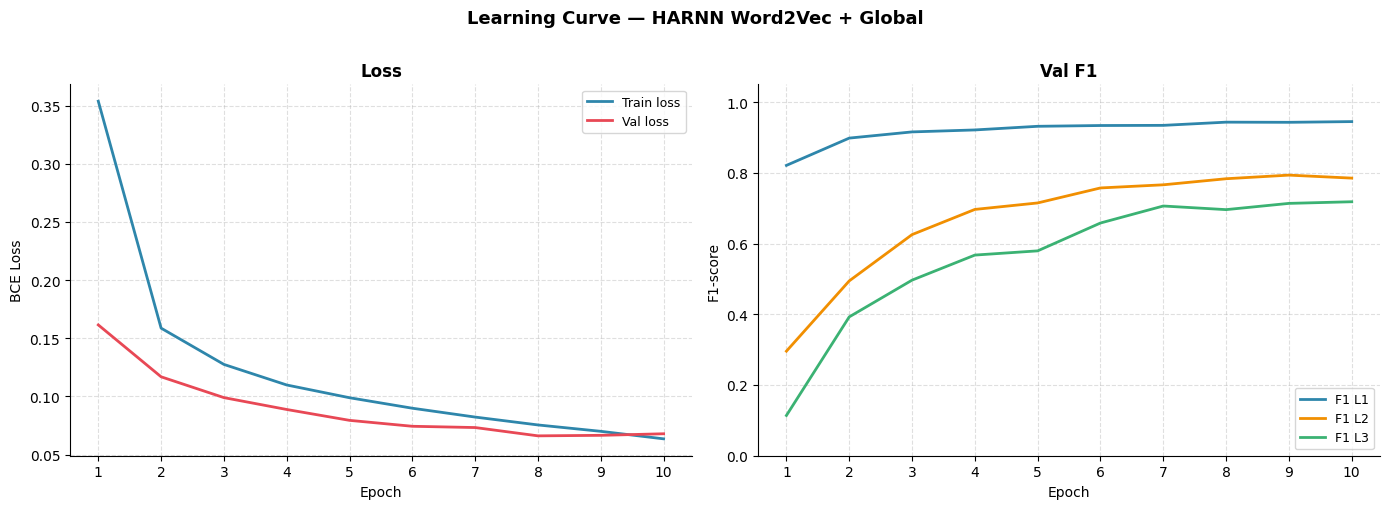

Saved: C:\Users\PC\Multi-Label-Text-Classification\output\figures\learning_curve.png


In [12]:
history = json.load(open(OUTPUT_DIR / "results" / "train_history.json"))
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Learning Curve — HARNN Word2Vec + Global", fontsize=13, fontweight="bold", y=1.01)

ax = axes[0]
for key, color, label in [
    ("train_loss", "#2E86AB", "Train loss"),
    ("val_loss", "#E84855", "Val loss"),
]:
    ax.plot(epochs, history[key], color=color, linewidth=2, label=label)
ax.set_title("Loss", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("BCE Loss", fontsize=10)

ax = axes[1]
for key, color, label in [
    ("val_f1_l1", "#2E86AB", "F1 L1"),
    ("val_f1_l2", "#F18F01", "F1 L2"),
    ("val_f1_l3", "#3BB273", "F1 L3"),
]:
    ax.plot(epochs, history[key], color=color, linewidth=2, label=label)
ax.set_title("Val F1", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch", fontsize=10)
ax.set_ylabel("F1-score", fontsize=10)
ax.set_ylim(0, 1.05)

for ax in axes:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9, framealpha=0.8, loc="lower right" if ax is axes[1] else "best")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig_path = OUTPUT_DIR / "figures" / "learning_curve.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


---
# Phần 3: Dự đoán (Prediction)


## Cell 3.1 — Load model cho predict


In [28]:
with open(OUT_VOCAB, encoding='utf-8') as f: vocab = json.load(f)
with open(OUT_LABEL_MAP, encoding='utf-8') as f: label_map = json.load(f)
with open(STOPWORDS_FILE, encoding='utf-8') as f:
    STOPWORDS = {line.strip() for line in f if line.strip()}

IDX_TO_LABEL = {
    level: {int(v): k for k, v in label_map[level].items()}
    for level in ['l1', 'l2', 'l3']
}
NUM_CLASSES_P = [len(label_map['l1']), len(label_map['l2']), len(label_map['l3'])]

CKPT_PRED = OUTPUT_DIR / 'models' / 'checkpoints' / 'best_model.pt'

# ── Dùng lại class HARNN từ training (đã khớp checkpoint key: emb.weight) ──
pred_model = HARNN(len(vocab), EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES_P).to(device)
ckpt = torch.load(CKPT_PRED, map_location=device)
pred_model.load_state_dict(ckpt['model_state'])
pred_model.eval()
print(f'Loaded checkpoint epoch {ckpt["epoch"]}')


Loaded checkpoint epoch 9


## Cell 3.2 — Hàm predict


In [ ]:
def clean_text(text: str) -> str:
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def tokenize(text: str) -> list[str]:
    try:
        from underthesea import word_tokenize
        tokens = word_tokenize(clean_text(text), format='text').split()
    except ImportError:
        tokens = clean_text(text).split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

def text_to_tensor(text: str) -> torch.Tensor:
    tokens = tokenize(text)
    ids    = [vocab.get(t, 1) for t in tokens][:MAX_LEN]
    ids   += [0] * (MAX_LEN - len(ids))
    return torch.tensor([ids], dtype=torch.long).to(device)

@torch.no_grad()
def predict(
    text: str,
    threshold: float = THRESHOLD,
    top_k: int = 3,
) -> dict:
    x      = text_to_tensor(text)
    preds  = [torch.sigmoid(p) for p in pred_model(x)]
    tokens = tokenize(text)

    result = {'tokens': tokens[:10]}

    for i, level in enumerate(['l1', 'l2', 'l3']):
        probs     = preds[i][0].cpu().numpy()
        idx2label = IDX_TO_LABEL[level]

        current_threshold = 0.1 if level == 'l3' else threshold

        selected = [
            {'label': idx2label[j], 'prob': float(probs[j])}
            for j in range(len(probs))
            if probs[j] >= current_threshold
        ]

        if not selected:
            top_indices = np.argsort(probs)[::-1][:top_k]
            selected    = [
                {'label': idx2label[j], 'prob': float(probs[j])}
                for j in top_indices
            ]

        selected.sort(key=lambda x: x['prob'], reverse=True)
        result[level] = selected

    return result


def print_result(text: str, result: dict) -> None:
    print('─' * 60)
    print(f'Văn bản : {text[:80]}...' if len(text) > 80 else f'Văn bản : {text}')
    print(f'Tokens  : {result["tokens"]} ...')
    print()
    for level in ['l1', 'l2', 'l3']:
        labels = result[level]
        print(f'  {level.upper()}:')
        for item in labels:
            bar   = '█' * int(item['prob'] * 20)
            mark  = '✓' if item['prob'] >= THRESHOLD else '·'
            print(f'    {mark} {item["label"]:<25} {item["prob"]:>5.1%}  {bar}')
    print()

print('Hàm predict sẵn sàng!')


SyntaxError: invalid character '─' (U+2500) (677639788.py, line 60)

## Cell 3.3 — Predict bài viết mẫu


In [ ]:
YOUR_TEXT = """
(Dân trí) - Google - công ty con của tập đoàn Alphabet - vừa công bố khoản chi trị giá 1 tỷ USD sử dụng trong vòng 3 năm nhằm hỗ trợ đào tạo về trí tuệ nhân tạo (AI) tại các trường đại học trên khắp nước Mỹ.
Tính đến nay, hơn 100 trường đại học của Mỹ đã đăng ký tham gia kế hoạch này của Google, bao gồm một số hệ thống trường đại học công lập lớn nhất nước Mỹ như Texas A&M hay Đại học Bắc Carolina.
"""

if YOUR_TEXT.strip():
    result = predict(YOUR_TEXT)
    print_result(YOUR_TEXT, result)
else:
    print('Thay YOUR_TEXT bằng nội dung bài viết của bạn')


---
# Phần 4: Đánh giá mô hình (Evaluation)


## Cell 4.1 — Load model & test data cho evaluation


In [ ]:
EVAL_BATCH_SIZE = 64
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / 'test_data.json', encoding='utf-8') as f:
    test_articles = json.load(f)
with open(OUT_VOCAB, encoding='utf-8') as f:
    vocab = json.load(f)
with open(OUT_LABEL_MAP, encoding='utf-8') as f:
    label_map = json.load(f)

VOCAB_SIZE_E = len(vocab)
NUM_CLASSES_E = [len(label_map['l1']), len(label_map['l2']), len(label_map['l3'])]
IDX2LABEL = {lv: {int(v): k for k, v in label_map[lv].items()} for lv in ['l1', 'l2', 'l3']}

eval_test_set = VnExpressDataset(test_articles, vocab)
eval_test_loader = DataLoader(eval_test_set, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Test set: {len(eval_test_set)} bài')

eval_model = HARNN(VOCAB_SIZE_E, EMBED_DIM, HIDDEN_SIZE, NUM_CLASSES_E).to(device)
CKPT_EVAL = OUTPUT_DIR / 'models' / 'checkpoints' / 'best_model.pt'
ckpt = torch.load(CKPT_EVAL, map_location=device)
eval_model.load_state_dict(ckpt['model_state'])
eval_model.eval()
print(f"Checkpoint: epoch {ckpt['epoch']}  val F1-L1={ckpt['val_f1_l1']:.3f}")

@torch.no_grad()
def get_preds_labels():
    probs_per_level = [[] for _ in range(3)]
    labels_per_level = [[] for _ in range(3)]
    for ids, l1, l2, l3 in eval_test_loader:
        out = eval_model(ids.to(device))
        for i, lbl in enumerate([l1, l2, l3]):
            probs_per_level[i].append(out[i].cpu().numpy())
            labels_per_level[i].append(lbl.numpy())
    return [np.concatenate(x) for x in probs_per_level], [np.concatenate(x) for x in labels_per_level]

probs, labels = get_preds_labels()
true_class = [np.argmax(labels[i], axis=1) for i in range(3)]
pred_class = [np.argmax(probs[i], axis=1) for i in range(3)]

l3_valid_mask = labels[2].sum(axis=1) > 0
true_l3_valid = true_class[2][l3_valid_mask]
pred_l3_valid = pred_class[2][l3_valid_mask]

l3_to_l2 = {}
true_l2_all = true_class[1]
for l3_idx in range(NUM_CLASSES_E[2]):
    idx = np.where(labels[2][:, l3_idx] > 0)[0]
    if len(idx):
        l3_to_l2[l3_idx] = int(np.bincount(true_l2_all[idx], minlength=NUM_CLASSES_E[1]).argmax())

print(f'Predictions collected: {len(true_class[0])} bài')
print(f'L3 valid samples: {l3_valid_mask.sum()} / {len(l3_valid_mask)} bài')
print(f'L3->L2 map inferred for {len(l3_to_l2)} / {NUM_CLASSES_E[2]} nhãn L3')


## Cell 4.2 — Confusion Matrix L1, L2, L3(valid)


In [ ]:
eval_for_cm = [
    ('L1', true_class[0], pred_class[0], [IDX2LABEL['l1'][i] for i in range(NUM_CLASSES_E[0])]),
    ('L2', true_class[1], pred_class[1], [IDX2LABEL['l2'][i] for i in range(NUM_CLASSES_E[1])]),
    ('L3(valid)', true_l3_valid, pred_l3_valid, [IDX2LABEL['l3'][i] for i in range(NUM_CLASSES_E[2])]),
]

def plot_confusion(level, y_true, y_pred, label_names, save_name, normalize=False, top_k=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    all_idx = np.arange(len(label_names))

    if top_k is not None and top_k < len(label_names):
        support = np.bincount(y_true, minlength=len(label_names))
        selected = np.argsort(support)[::-1][:top_k]
        selected = np.sort(selected)
    else:
        selected = all_idx

    cm = confusion_matrix(y_true, y_pred, labels=selected)
    display_labels = [label_names[i] for i in selected]

    if normalize:
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm, row_sum, out=np.zeros_like(cm, dtype=float), where=row_sum != 0)
    else:
        cm_plot = cm

    n = len(display_labels)
    fig_w = max(10, min(26, 0.55 * n))
    fig_h = max(8, min(22, 0.50 * n))
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_plot, display_labels=display_labels)
    fmt = '.2f' if normalize else 'd'
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=75, values_format=fmt, colorbar=True)

    metric_note = ' (normalized)' if normalize else ' (count)'
    top_note = f' - top {top_k} labels' if top_k is not None and top_k < len(label_names) else ''
    ax.set_title(f'Confusion Matrix {level}{metric_note}{top_note}', fontsize=13, pad=12)
    ax.set_xlabel('Du doan', fontsize=11)
    ax.set_ylabel('Thuc te', fontsize=11)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / save_name, dpi=170, bbox_inches='tight')
    plt.show()

plot_confusion('L1', true_class[0], pred_class[0], eval_for_cm[0][3], 'confusion_matrix_l1_full.png', normalize=False)
plot_confusion('L2', true_class[1], pred_class[1], eval_for_cm[1][3], 'confusion_matrix_l2_top20_norm.png', normalize=True, top_k=20)
plot_confusion('L3(valid)', true_l3_valid, pred_l3_valid, eval_for_cm[2][3], 'confusion_matrix_l3_top25_norm.png', normalize=True, top_k=25)

for lv, y_true, y_pred, label_names in eval_for_cm:
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(label_names)))
    errors = [
        (cm[i, j], label_names[i], label_names[j])
        for i in range(len(label_names))
        for j in range(len(label_names))
        if i != j and cm[i, j] > 0
    ]
    print(f'\nTop nham lan {lv}:')
    for cnt, true, pred in sorted(errors, reverse=True)[:10]:
        print(f'  {true:<22} -> {pred:<22}  {cnt} bai')


## Cell 4.3 — Accuracy, Precision, Recall, F1 (Macro/Micro)


In [ ]:
levels = ['L1', 'L2', 'L3(valid)']
eval_sets = [
    ('L1', true_class[0], pred_class[0]),
    ('L2', true_class[1], pred_class[1]),
    ('L3(valid)', true_l3_valid, pred_l3_valid),
]

def calc_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision_micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Recall_micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'F1_micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'Precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

metrics_rows = []
for lv, y_true, y_pred in eval_sets:
    row = {'Level': lv}
    row.update(calc_metrics(y_true, y_pred))
    metrics_rows.append(row)

print('EVALUATION (L3 chỉ tính trên mẫu có nhãn L3 thật):')
header = f"{'Level':<10} {'Accuracy':>9} {'P_micro':>9} {'R_micro':>9} {'F1_micro':>9} {'P_macro':>9} {'R_macro':>9} {'F1_macro':>9}"
print('-' * len(header))
print(header)
print('-' * len(header))
for r in metrics_rows:
    print(
        f"{r['Level']:<10} {r['Accuracy']:>9.3f} {r['Precision_micro']:>9.3f} {r['Recall_micro']:>9.3f} "
        f"{r['F1_micro']:>9.3f} {r['Precision_macro']:>9.3f} {r['Recall_macro']:>9.3f} {r['F1_macro']:>9.3f}"
    )
print('-' * len(header))

pred_l2_valid = pred_class[1][l3_valid_mask]
true_l2_valid = true_class[1][l3_valid_mask]
pred_l3_parent = np.array([l3_to_l2.get(int(c), -1) for c in pred_l3_valid])
hier_parent_consistency = (pred_l3_parent == pred_l2_valid).mean()
hier_strict_acc = ((pred_l3_valid == true_l3_valid) & (pred_l2_valid == true_l2_valid)).mean()

print('\nHIERARCHY DIAGNOSTICS (L3):')
print(f'- Parent consistency: {hier_parent_consistency:.3f}')
print(f'- Strict hierarchical accuracy: {hier_strict_acc:.3f}')

print('\nSỐ LƯỢNG BÀI TEST THEO TỪNG MỨC:')
print(f'L1: {len(true_class[0])} bài test')
print(f'L2: {len(true_class[1])} bài test')
print(f'L3: {len(true_l3_valid)} bài test')

x = np.arange(len(levels))
width = 0.16
acc = [r['Accuracy'] for r in metrics_rows]
pre = [r['Precision_macro'] for r in metrics_rows]
rec = [r['Recall_macro'] for r in metrics_rows]
f1m = [r['F1_macro'] for r in metrics_rows]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 1.5 * width, acc, width, label='Accuracy', color='#3498db', edgecolor='white', linewidth=1)
ax.bar(x - 0.5 * width, pre, width, label='Precision (macro)', color='#f39c12', edgecolor='white', linewidth=1)
ax.bar(x + 0.5 * width, rec, width, label='Recall (macro)', color='#2ecc71', edgecolor='white', linewidth=1)
ax.bar(x + 1.5 * width, f1m, width, label='F1-score (macro)', color='#9b59b6', edgecolor='white', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('EVALUATION')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'basic_metrics_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
